In [4]:
import numpy as np
import pandas as pd
df = pd.read_csv("SeoulBikeData.csv", delimiter=",", encoding="ISO-8859-1")

In [19]:
df.head()

,Date,Rented Bike Count,Hour,Temperature(Â°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(Â°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,2017-12-01,254,0.0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,2017-12-01,204,1.0,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,2017-12-01,173,2.0,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,2017-12-01,107,3.0,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,2017-12-01,78,4.0,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8760 entries, 2017-12-01 00:00:00 to 2018-11-30 23:00:00
Freq: h
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Date                        8760 non-null   object 
 1   Rented Bike Count           8756 non-null   float64
 2   Hour                        8760 non-null   float64
 3   Temperature(Â°C)            8756 non-null   float64
 4   Humidity(%)                 8756 non-null   float64
 5   Wind speed (m/s)            8756 non-null   float64
 6   Visibility (10m)            8756 non-null   float64
 7   Dew point temperature(Â°C)  8756 non-null   float64
 8   Solar Radiation (MJ/m2)     8756 non-null   float64
 9   Rainfall(mm)                8756 non-null   float64
 10  Snowfall (cm)               8756 non-null   float64
 11  Seasons                     8706 non-null   object 
 12  Holiday                     8756 non-null   ob

In [25]:
# Select columns with 'object' dtype
object_columns = df.select_dtypes(include=['object']).columns

# Iterate through each object column and print its unique categories
for col in object_columns:
    print(f"--- Categories in '{col}': ---")
    print(df[col].unique())
    print(f"Number of unique categories: {df[col].nunique()}")
    print()

--- Categories in 'Date': ---
[datetime.date(2017, 12, 1) datetime.date(2017, 12, 2)
 datetime.date(2017, 12, 3) datetime.date(2017, 12, 4)
 datetime.date(2017, 12, 5) datetime.date(2017, 12, 6)
 datetime.date(2017, 12, 7) datetime.date(2017, 12, 8)
 datetime.date(2017, 12, 9) datetime.date(2017, 12, 10)
 datetime.date(2017, 12, 11) datetime.date(2017, 12, 12)
 datetime.date(2017, 12, 13) datetime.date(2017, 12, 14)
 datetime.date(2017, 12, 15) datetime.date(2017, 12, 16)
 datetime.date(2017, 12, 17) datetime.date(2017, 12, 18)
 datetime.date(2017, 12, 19) datetime.date(2017, 12, 20)
 datetime.date(2017, 12, 21) datetime.date(2017, 12, 22)
 datetime.date(2017, 12, 23) datetime.date(2017, 12, 24)
 datetime.date(2017, 12, 25) datetime.date(2017, 12, 26)
 datetime.date(2017, 12, 27) datetime.date(2017, 12, 28)
 datetime.date(2017, 12, 29) datetime.date(2017, 12, 30)
 datetime.date(2017, 12, 31) datetime.date(2018, 1, 1)
 datetime.date(2018, 1, 2) datetime.date(2018, 1, 3)
 datetime.date(2

In [6]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values

,0
Date,0
Rented Bike Count,0
Hour,4
Temperature(Â°C),0
Humidity(%),0
Wind speed (m/s),0
Visibility (10m),0
Dew point temperature(Â°C),0
Solar Radiation (MJ/m2),0
Rainfall(mm),0


In [7]:
# Convert 'Date' column to datetime (this keeps the time part initially)
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

# Start Date: The earliest date in the 'Date' column
start_date = df['Date'].min().date()  # Extracts only the date part (no time)

# End Date: The latest date in the 'Date' column
end_date = df['Date'].max().date()  # Extracts only the date part (no time)

# Strip the time component from 'Date' for consistent comparison
df['Date'] = df['Date'].dt.date

# Smallest Hour for Start Date: The smallest hour on the start date
start_hour = df[df['Date'] == start_date]['Hour'].min()

# Largest Hour for End Date: The largest hour on the end date
end_hour = df[df['Date'] == end_date]['Hour'].max()

hour_range = df['Hour'].unique()

print(f"Start Date: {start_date}")
print(f"End Date: {end_date}")
print(f"Smallest Hour for Start Date: {start_hour}")
print(f"Largest Hour for End Date: {end_hour}")

Start Date: 2017-12-01
End Date: 2018-11-30
Smallest Hour for Start Date: 0.0
Largest Hour for End Date: 23.0


In [23]:
# Create a reference set of all possible hours (0 to 23)
full_hour_range = set(range(24))

# Group by Date and check if each day has all 24 hours
missing_hours = []

# Iterate over each unique date
for date, group in df.groupby('Date'):
    # Get unique hours for the current date
    unique_hours = set(group['Hour'].unique())

    # Compare the unique hours with the full range (0-23)
    if unique_hours != full_hour_range:
        missing_hours.append(date)

if missing_hours:
    print("The following dates are missing some hours:")
    for date in missing_hours:
        print(date)
else:
    print("All dates have the full range of hours (0-23).")

All dates have the full range of hours (0-23).


In [9]:
# Get summary statistics for numerical variables (excluding 'Hour')
df.drop(columns='Hour').describe()

,Rented Bike Count,Temperature(Â°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(Â°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,12.882922,58.226256,70.215799,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,11.944825,20.362413,6410.589324,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,-17.800000,0.000000,-3.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,39.400000,98.000000,600000.000000,2000.000000,27.200000,3.520000,35.000000,8.800000


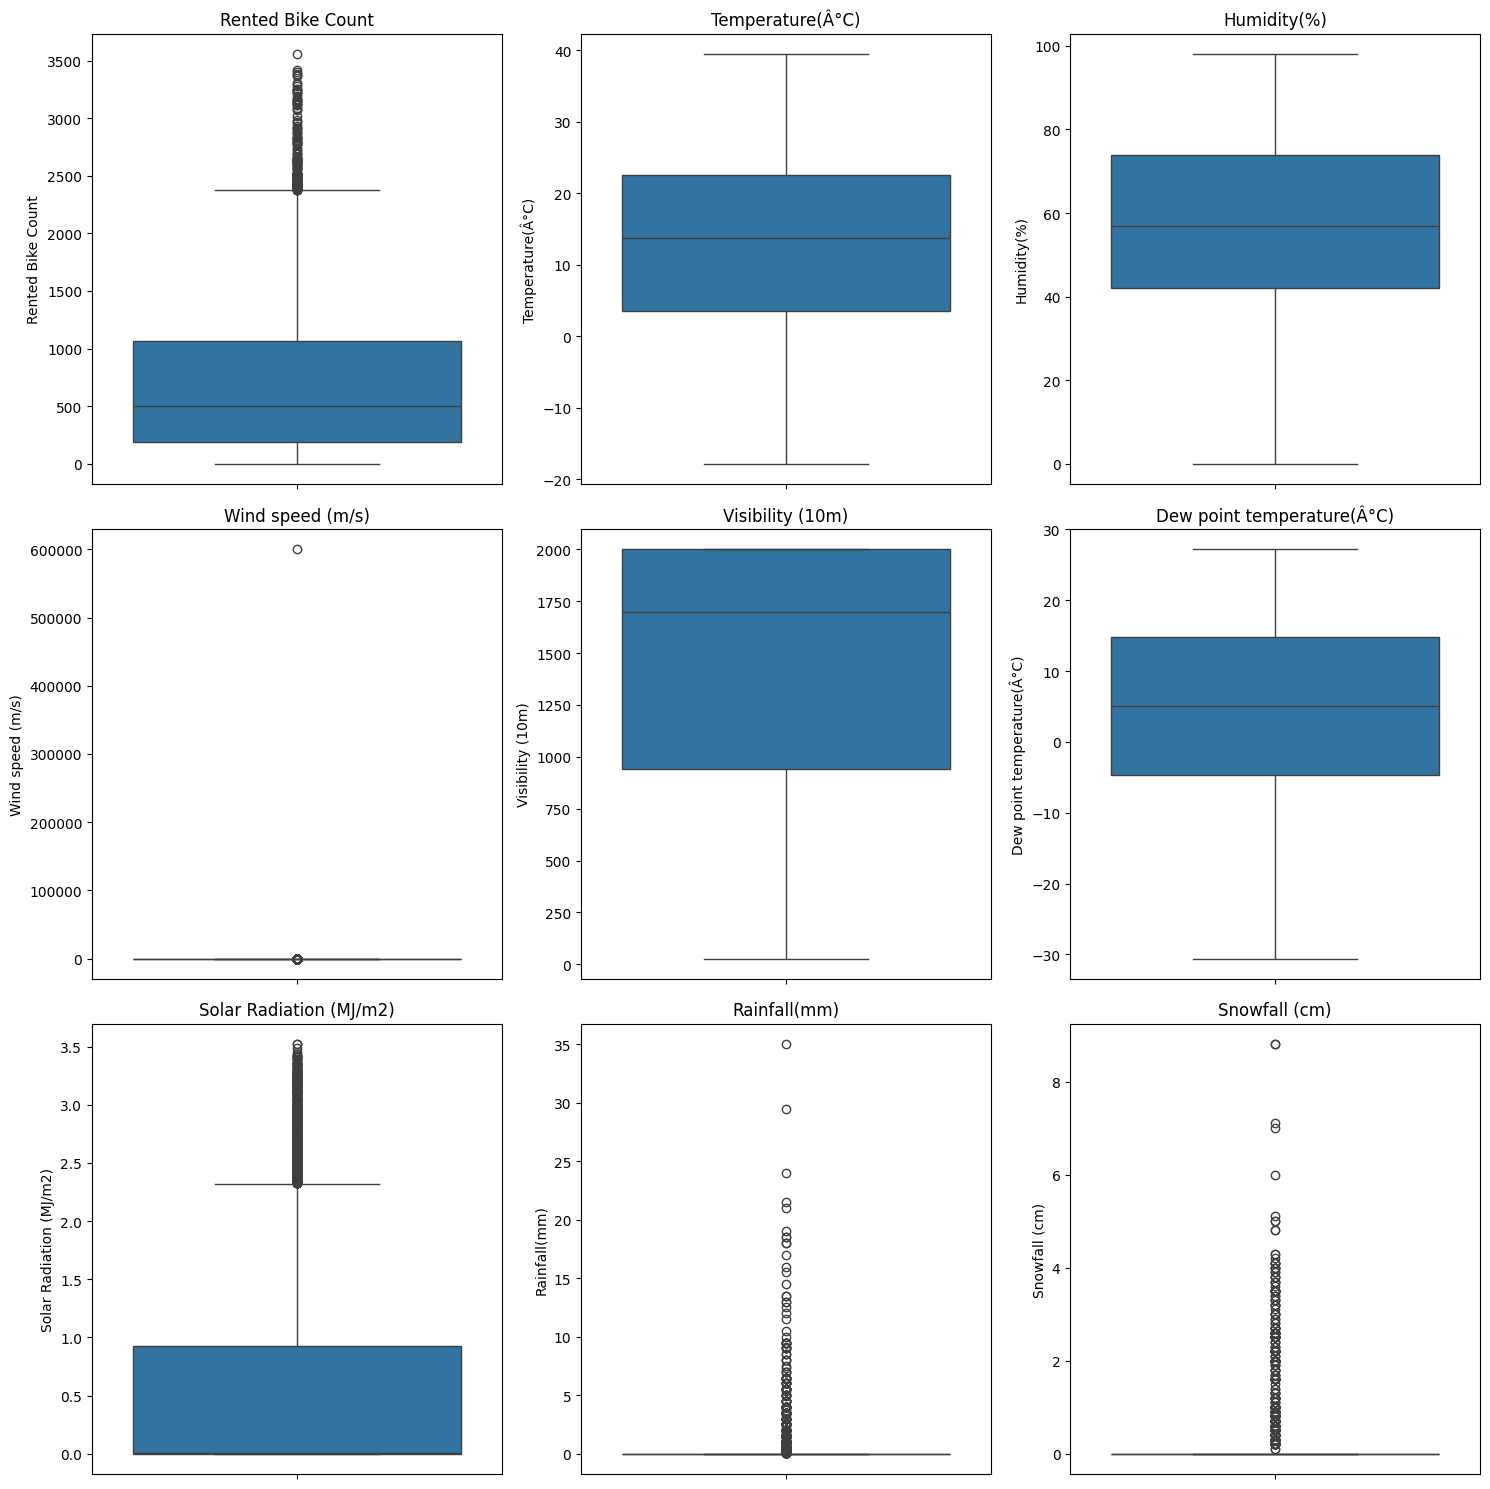

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

# Select only numeric columns and drop the 'Hour' column
numeric_df = df.select_dtypes(include=['number']).drop('Hour', axis=1)

# Loop through each numeric column and plot a boxplot
for i, col in enumerate(numeric_df.columns):
    sns.boxplot(data=df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

# Remove any unused axes
for j in range(len(numeric_df.columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [11]:
from scipy.stats import zscore

# Apply Z-score to the numeric columns
z_scores = numeric_df.apply(zscore)

# Identify outliers on both low and high ends
low_end_outliers = (z_scores < -3).sum()  # Count of outliers less than -3
high_end_outliers = (z_scores > 3).sum()  # Count of outliers greater than 3

print("Sum of outliers on low-end:")
print(low_end_outliers)
print()

print("Sum of outliers on high-end:")
print(high_end_outliers)

Sum of outliers on low-end:
Rented Bike Count             0
Temperature(Â°C)              0
Humidity(%)                   0
Wind speed (m/s)              0
Visibility (10m)              0
Dew point temperature(Â°C)    0
Solar Radiation (MJ/m2)       0
Rainfall(mm)                  0
Snowfall (cm)                 0
dtype: int64

Sum of outliers on high-end:
Rented Bike Count              67
Temperature(Â°C)                0
Humidity(%)                     0
Wind speed (m/s)                1
Visibility (10m)                0
Dew point temperature(Â°C)      0
Solar Radiation (MJ/m2)        85
Rainfall(mm)                   94
Snowfall (cm)                 173
dtype: int64


In [12]:
columns_to_check = ['Rented Bike Count', 'Wind speed (m/s)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)']

top_10_highest_values = {}
for col in columns_to_check:
    top_10_highest_values[col] = df[col].nlargest(10)

for col, values in top_10_highest_values.items():
    print(f"Top 10 highest values for {col}:")
    print(values)
    print()

Top 10 highest values for Rented Bike Count:
4818    3556
4866    3418
4650    3404
4842    3384
4458    3380
4890    3365
4554    3309
6810    3298
6978    3277
6858    3256
Name: Rented Bike Count, dtype: int64

Top 10 highest values for Wind speed (m/s):
1078    600000.0
3134         7.4
3141         7.3
3138         7.2
6316         6.9
933          6.7
3140         6.1
1309         6.0
2174         6.0
87           5.8
Name: Wind speed (m/s), dtype: float64

Top 10 highest values for Solar Radiation (MJ/m2):
4069    3.52
4165    3.52
4117    3.49
6205    3.45
4164    3.44
4068    3.42
4405    3.42
4717    3.42
4861    3.42
4166    3.41
Name: Solar Radiation (MJ/m2), dtype: float64

Top 10 highest values for Rainfall(mm):
3997    35.0
6501    29.5
5132    24.0
5034    21.5
6524    21.0
4012    19.0
5099    18.5
6498    18.5
8229    18.0
8232    18.0
Name: Rainfall(mm), dtype: float64

Top 10 highest values for Snowfall (cm):
8602    8.8
8603    8.8
8601    7.1
8604    7.0
8605    6

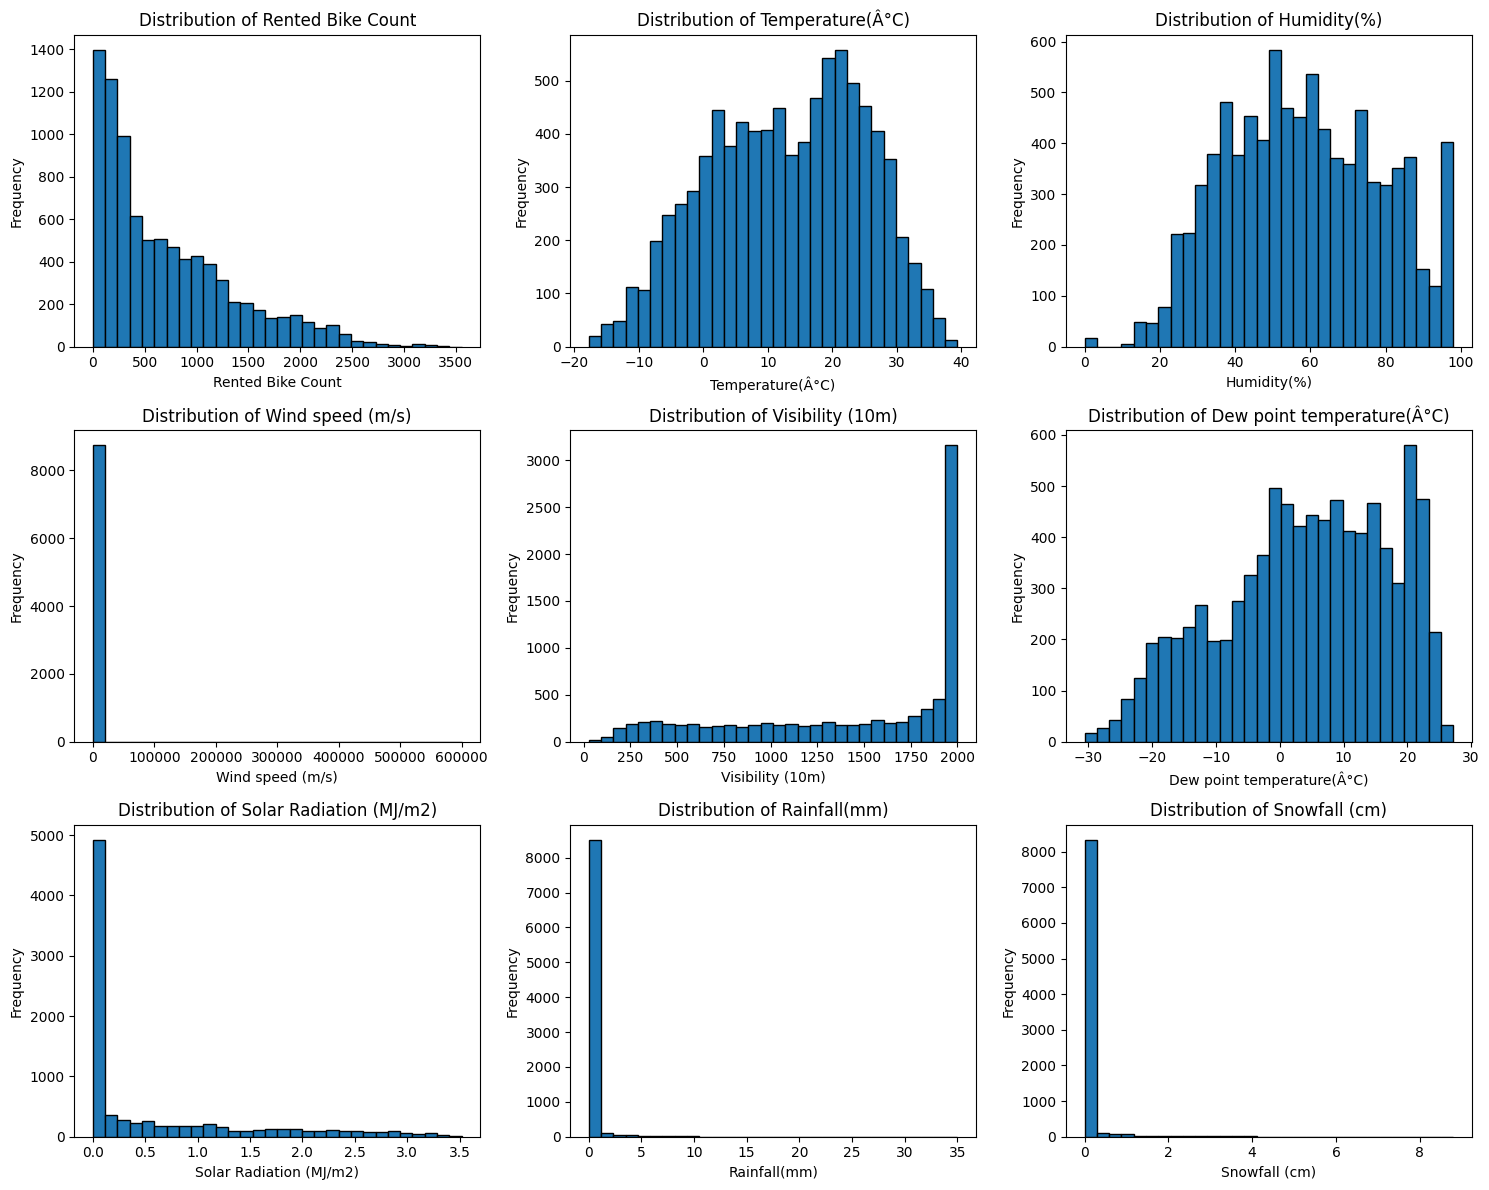

In [13]:
# Plot histograms for each numerical column (excluding 'Hour')
numerical_columns = df.select_dtypes(include='number').columns
numerical_columns = numerical_columns[numerical_columns != 'Hour']  # Exclude 'Hour' from numerical columns

num_columns = 3
num_rows = (len(numerical_columns) // num_columns) + (len(numerical_columns) % num_columns > 0)

fig, axes = plt.subplots(num_rows, num_columns, figsize=(15, 12))

axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    axes[i].hist(df[col], bins=30, edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

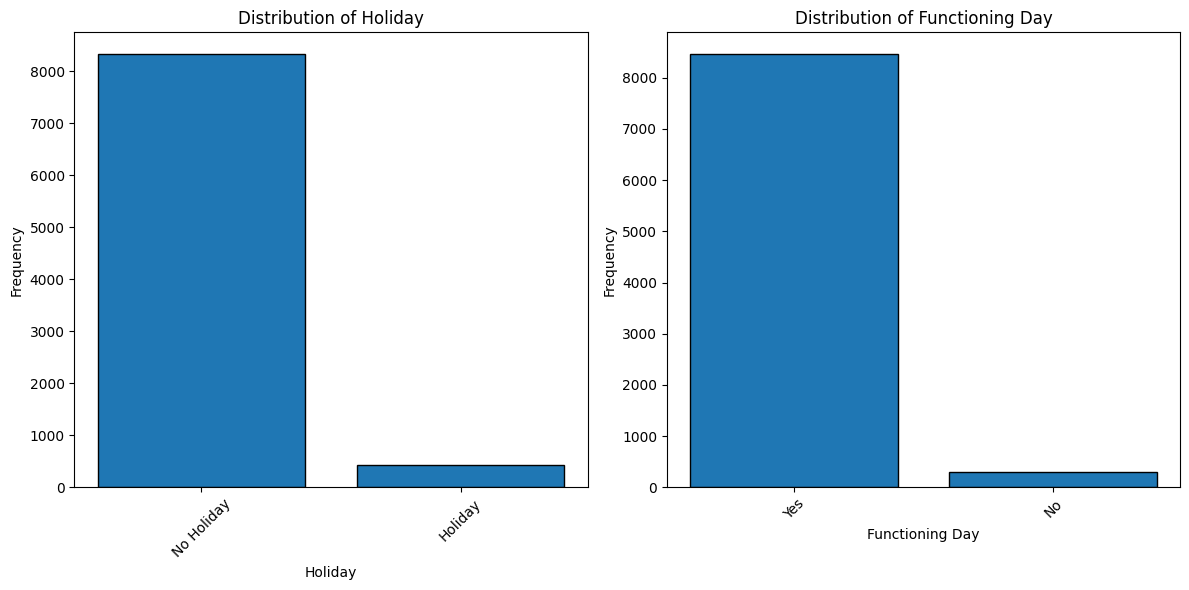

In [14]:
categorical_columns = ['Holiday', 'Functioning Day']

num_columns = len(categorical_columns)
num_rows = 1

fig, axes = plt.subplots(num_rows, num_columns, figsize=(12, 6))

for i, col in enumerate(categorical_columns):
    axes[i].bar(df[col].value_counts().index, df[col].value_counts().values, edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [15]:
count_zero_bike_entries = df[df['Rented Bike Count'] == 0].shape[0]

print(f"Number of entries where Rented Bike Count is 0: {count_zero_bike_entries}")

Number of entries where Rented Bike Count is 0: 295


In [16]:
# Cleaning data

In [17]:
# Create a boolean mask to filter rows where ALL column Z-scores are within [-3, 3]
# .abs() < 3 covers both high-end (> 3) and low-end (< -3) outliers
is_within_range = (z_scores.abs() < 3).all(axis=1)

# Apply the mask to create a cleaned DataFrame
df_clean = numeric_df[is_within_range]

# Summary of the filtering process
print(f"Original row count: {len(numeric_df)}")
print(f"Cleaned row count:  {len(df_clean)}")
print(f"Total rows removed: {len(numeric_df) - len(df_clean)}")

Original row count: 8760
Cleaned row count:  8342
Total rows removed: 418


In [22]:
import pandas as pd

# 1. Ensure 'Date' is in datetime format, ignoring errors for a moment
df['Date'] = pd.to_datetime(df['Date'])

# 2. Create Timestamp by adding Date and Hour (as a time duration)
# This handles floats like 14.0 correctly and ignores NaNs during addition
df['Timestamp'] = df['Date'] + pd.to_timedelta(df['Hour'], unit='h')

# 3. Drop rows where Timestamp is NaT (Not a Time) before reindexing
df = df.dropna(subset=['Timestamp']).set_index('Timestamp').sort_index()

# 4. Fill the gaps in the hourly timeline
df = df.asfreq('H')

# 5. Restore Hour and Date columns for all rows (including new ones)
df['Hour'] = df.index.hour.astype(float)
df['Date'] = df.index.date

df_final = df.reset_index(drop=True)

print(f"Fixed! Total rows: {len(df_final)}")

Fixed! Total rows: 8760


/tmp/ipykernel_7363/2731293226.py:14: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.asfreq('H')


In [28]:
# 1. Fill numerical columns using linear interpolation
num_cols = df_final.select_dtypes(include=['float64', 'int64']).columns
df_final[num_cols] = df_final[num_cols].interpolate(method='linear')

# 2. Fill categorical/object columns using forward and backward fill
obj_cols = df_final.select_dtypes(include=['object']).columns
df_final[obj_cols] = df_final[obj_cols].ffill().bfill()